In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
n_array = 10**np.arange(4,9)
numbers_sets_list = [np.random.uniform(0, 1, n).astype(np.float32) for n in n_array]
true_sums = [math.fsum(dataset) for dataset in numbers_sets_list]

a)

In [3]:
accumulators_array_a = np.array([np.float64(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    for number in dataset:
        accumulators_array_a[i]+=number
print(accumulators_array_a)

[5.01570884e+03 5.02495153e+04 5.00151066e+05 4.99890963e+06
 4.99961536e+07]


b)

In [4]:
accumulators_array_b = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    for number in dataset:
        accumulators_array_b[i]+=number
print(accumulators_array_b)

[5.0157065e+03 5.0249133e+04 5.0014519e+05 4.9989955e+06 1.6777216e+07]


c)

In [5]:
accumulators_array_c = np.array([np.float32(0.0)] * 5)

for i,dataset in enumerate(numbers_sets_list):
    error_c =  np.float32(0.0)
    for number in dataset:
        y = np.float32(number -error_c)
        temp = np.float32(accumulators_array_c[i] + y)
        error_c = np.float32((temp - accumulators_array_c[i]) - y)
        accumulators_array_c[i] = temp
print(accumulators_array_c)

[5.0157090e+03 5.0249516e+04 5.0015106e+05 4.9989095e+06 4.9996152e+07]


d)

In [6]:
accumulators_array_d = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    dataset = np.sort(dataset)
    numbers_sets_list[i] = dataset
    for number in dataset:
        accumulators_array_d[i]+=number
print(accumulators_array_d)

[5.0157046e+03 5.0249609e+04 5.0015056e+05 5.0568315e+06 1.6777216e+07]


e)

In [7]:
accumulators_array_e = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    dataset = np.sort(dataset)[::-1]
    numbers_sets_list[i] = dataset
    for number in dataset:
        accumulators_array_e[i]+=number
print(accumulators_array_e)

[5.0157163e+03 5.0249199e+04 5.0015156e+05 4.9989725e+06 1.6777216e+07]


In [8]:
print(f'true sums: {true_sums}')
print(f'accumulator a: {accumulators_array_a}')
print(f'accumulator b: {accumulators_array_b}')
print(f'accumulator c: {accumulators_array_c}')
print(f'accumulator d: {accumulators_array_d}')
print(f'accumulator e: {accumulators_array_e}')

true sums: [5015.708838354098, 50249.51529381845, 500151.06638364145, 4998909.625858159, 49996153.55809831]
accumulator a: [5.01570884e+03 5.02495153e+04 5.00151066e+05 4.99890963e+06
 4.99961536e+07]
accumulator b: [5.0157065e+03 5.0249133e+04 5.0014519e+05 4.9989955e+06 1.6777216e+07]
accumulator c: [5.0157090e+03 5.0249516e+04 5.0015106e+05 4.9989095e+06 4.9996152e+07]
accumulator d: [5.0157046e+03 5.0249609e+04 5.0015056e+05 5.0568315e+06 1.6777216e+07]
accumulator e: [5.0157163e+03 5.0249199e+04 5.0015156e+05 4.9989725e+06 1.6777216e+07]


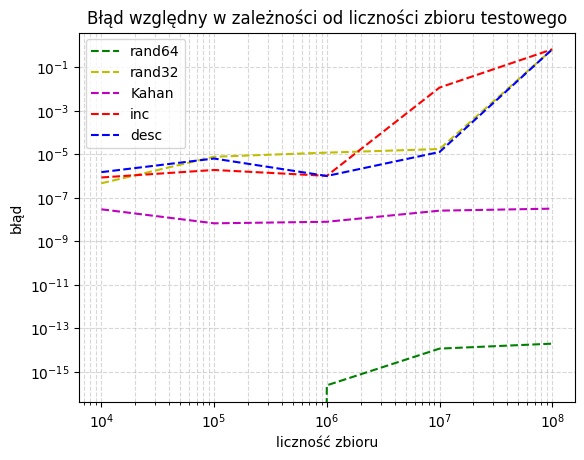

In [9]:
plt.loglog(n_array, abs(accumulators_array_a-true_sums)/true_sums, 'g--', label='rand64')
plt.loglog(n_array, abs(accumulators_array_b-true_sums)/true_sums, 'y--', label='rand32')
plt.loglog(n_array, abs(accumulators_array_c-true_sums)/true_sums, 'm--', label='Kahan')
plt.loglog(n_array, abs(accumulators_array_d-true_sums)/true_sums, 'r--', label='inc')
plt.loglog(n_array, abs(accumulators_array_e-true_sums)/(true_sums), 'b--', label='desc')
plt.title("Błąd względny w zależności od liczności zbioru testowego")
plt.xlabel("liczność zbioru")
plt.ylabel("błąd")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()